<a href="https://colab.research.google.com/github/maikol0629/dl_voice_command_cl/blob/main/04%20-%20arquitectura%20crnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelo CRNN: CNN 1D + BiLSTM para Clasificación de Comandos de Voz

In [1]:
# Colab setup
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import os
    try:
        from google.colab import userdata
        os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
        os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
    except Exception:
        pass

    !pip install -q kagglehub torch torchaudio pandas numpy matplotlib scikit-learn librosa soundfile audioread numba
    import kagglehub
    import shutil

    try:
        data_path = kagglehub.competition_download("voice-commands-classification-2026")
    except Exception as e:
        print("Error al descargar de Kaggle. Asegúrate de configurar KAGGLE_USERNAME y KAGGLE_KEY en tus Colab Secrets.")
        raise e

    if not os.path.exists('data'):
        os.symlink(data_path, 'data')

    if not os.path.exists('dl_voice_command_cl'):
        !git clone https://github.com/maikol0629/dl_voice_command_cl.git

    for f in ['train_metadata.csv', 'test_metadata.csv']:
        src = os.path.join('dl_voice_command_cl', f)
        if os.path.exists(src) and not os.path.exists(f):
            shutil.copy(src, '.')
    for f in ['models.py', 'data.py']:
        src = os.path.join('dl_voice_command_cl', f)
        if os.path.exists(src) and not os.path.exists(f):
            shutil.copy(src, '.')

    DATA_PATH = os.path.join(data_path, 'train')
else:
    DATA_PATH = './data/train'


100%|██████████| 3.31G/3.31G [03:02<00:00, 19.5MB/s]

Extracting files...


Cloning into 'dl_voice_command_cl'...
remote: Enumerating objects: 38, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 38 (delta 17), reused 28 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (38/38), 2.02 MiB | 4.61 MiB/s, done.
Resolving deltas: 100% (17/17), done.


In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchaudio.transforms as T

from models import AudioToMelSpectrogram, CRNNModel
from data import load_data
from sklearn.metrics import confusion_matrix, classification_report

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


In [3]:
SAMPLE_RATE = 16000
BATCH_SIZE = 64
EPOCHS = 20
LR = 0.001
N_CLASSES = 35
N_MELS = 64
N_FFT = 1024
HOP_LENGTH = 256
N_CHANNEL = 32
PATIENCE = 5
VAL_SIZE = 0.2
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

In [4]:
# VoiceCommandsDataset is now imported from data.py


In [5]:
AUDIO_DIR = os.path.join(DATA_PATH, 'train', 'train')

train_loader, val_loader, label_encoder, num_classes = load_data(
    train_metadata_csv='train_metadata.csv',
    train_audio_dir=AUDIO_DIR,
    val_size=VAL_SIZE, seed=SEED,
    batch_size=BATCH_SIZE,
)

print(f"Numero de clases: {num_classes}")
print("Clases:", list(label_encoder.classes_))
total = len(train_loader.dataset) + len(val_loader.dataset)
print(f"Total muestras: {total}")
print(f"Train: {len(train_loader.dataset)} | Val: {len(val_loader.dataset)}")

Numero de clases: 35
Clases: ['backward', 'bed', 'bird', 'cat', 'dog', 'down', 'eight', 'five', 'follow', 'forward', 'four', 'go', 'happy', 'house', 'learn', 'left', 'marvin', 'nine', 'no', 'off', 'on', 'one', 'right', 'seven', 'sheila', 'six', 'stop', 'three', 'tree', 'two', 'up', 'visual', 'wow', 'yes', 'zero']
Total muestras: 95246
Train: 76196 | Val: 19050


In [6]:
# Crear transformación a Mel-spectrogram
audio_transform = AudioToMelSpectrogram(
    sample_rate=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
).to(device)


In [7]:
model = CRNNModel(num_classes=num_classes).to(device)
print(model)

# Verificar con un batch dummy
dummy = torch.randn(2, 1, N_MELS, 63).to(device)
out = model(dummy)
print(f"Salida shape: {out.shape}")

CRNNModel(
  (cnn): Sequential(
    (0): Conv1d(1, 32, kernel_size=(80,), stride=(16,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (rnn): LSTM(32, 32, num_layers=2, batch_first=True, bidirectional=True)
  (classifier): Linear(in_features=64, out_features=35, bias=True)
)
Salida shape: torch.Size([2, 35])


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

In [9]:
best_val_loss = float('inf')
patience_counter = 0
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(EPOCHS):
    model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for waveforms, labels in train_loader:
        waveforms = waveforms.to(device)
        labels = labels.to(device)
        mels = audio_transform(waveforms)

        optimizer.zero_grad()
        outputs = model(mels)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * waveforms.size(0)
        preds = outputs.argmax(dim=1)
        train_total += labels.size(0)
        train_correct += (preds == labels).sum().item()

    epoch_train_loss = train_loss_sum / train_total
    epoch_train_acc = train_correct / train_total
    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)

    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for waveforms, labels in val_loader:
            waveforms = waveforms.to(device)
            labels = labels.to(device)
            mels = audio_transform(waveforms)
            outputs = model(mels)
            loss = criterion(outputs, labels)

            val_loss_sum += loss.item() * waveforms.size(0)
            preds = outputs.argmax(dim=1)
            val_total += labels.size(0)
            val_correct += (preds == labels).sum().item()

    epoch_val_loss = val_loss_sum / val_total
    epoch_val_acc = val_correct / val_total
    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc)

    scheduler.step(epoch_val_loss)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc * 100:.2f}% | "
        f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc * 100:.2f}%"
    )

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_crnn.pth')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping en epoca {epoch + 1}")
            break

print("Entrenamiento completado.")

Epoch 01/20 | Train Loss: 2.9616 Acc: 19.50% | Val Loss: 2.7345 Acc: 26.39%
Epoch 02/20 | Train Loss: 2.7484 Acc: 25.16% | Val Loss: 2.6351 Acc: 27.91%
Epoch 03/20 | Train Loss: 2.4567 Acc: 31.71% | Val Loss: 2.2708 Acc: 36.56%
Epoch 04/20 | Train Loss: 2.2155 Acc: 37.58% | Val Loss: 2.0500 Acc: 41.87%
Epoch 05/20 | Train Loss: 2.0872 Acc: 40.77% | Val Loss: 2.0116 Acc: 42.36%
Epoch 06/20 | Train Loss: 2.3284 Acc: 34.91% | Val Loss: 2.1365 Acc: 39.83%
Epoch 07/20 | Train Loss: 2.0924 Acc: 41.02% | Val Loss: 2.1299 Acc: 40.02%
Epoch 08/20 | Train Loss: 1.9930 Acc: 43.74% | Val Loss: 1.8136 Acc: 47.73%
Epoch 09/20 | Train Loss: 1.9894 Acc: 43.73% | Val Loss: 2.1194 Acc: 40.20%
Epoch 10/20 | Train Loss: 2.1511 Acc: 39.15% | Val Loss: 1.9556 Acc: 43.84%
Epoch 11/20 | Train Loss: 1.9075 Acc: 45.14% | Val Loss: 1.7778 Acc: 48.13%
Epoch 12/20 | Train Loss: 1.8242 Acc: 47.10% | Val Loss: 1.7252 Acc: 49.50%
Epoch 13/20 | Train Loss: 1.6859 Acc: 51.14% | Val Loss: 1.5737 Acc: 54.07%
Epoch 14/20 

In [10]:
model.load_state_dict(torch.load('best_crnn.pth', map_location=device))
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for waveforms, labels in val_loader:
        waveforms = waveforms.to(device)
        labels = labels.to(device)
        mels = audio_transform(waveforms)
        logits = model(mels)
        preds = logits.argmax(dim=1).cpu().numpy()
        y_pred.extend(preds.tolist())
        y_true.extend(labels.cpu().numpy().tolist())

val_acc = (np.array(y_true) == np.array(y_pred)).mean()
print(f"Accuracy en validacion: {val_acc * 100:.2f}%")

Accuracy en validacion: 64.37%


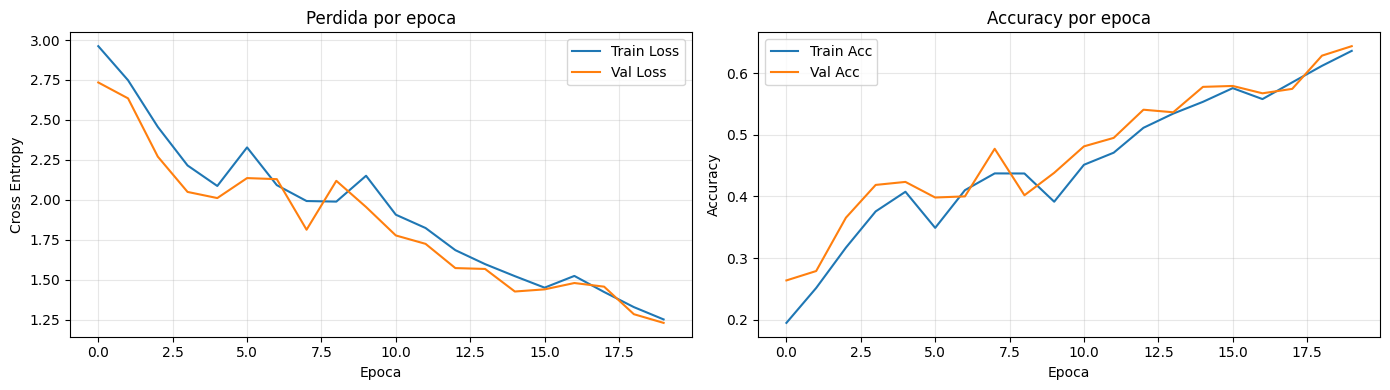

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_title('Perdida por epoca')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Cross Entropy')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(train_accs, label='Train Acc')
axes[1].plot(val_accs, label='Val Acc')
axes[1].set_title('Accuracy por epoca')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

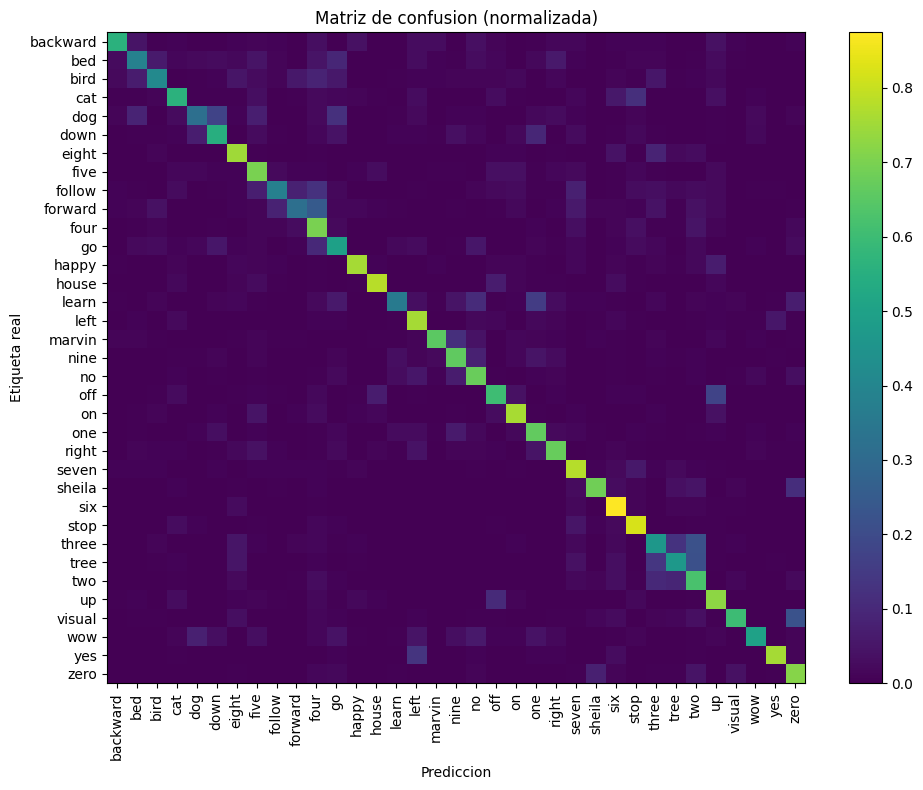

Reporte de clasificacion (validacion):
              precision    recall  f1-score   support

    backward       0.72      0.56      0.63       296
         bed       0.49      0.38      0.43       363
        bird       0.55      0.41      0.47       373
         cat       0.53      0.56      0.55       364
         dog       0.48      0.32      0.39       383
        down       0.65      0.55      0.60       702
       eight       0.73      0.75      0.74       683
        five       0.66      0.70      0.68       731
      follow       0.53      0.38      0.44       284
     forward       0.43      0.32      0.37       278
        four       0.53      0.70      0.60       674
          go       0.54      0.50      0.52       700
       happy       0.77      0.76      0.76       368
       house       0.73      0.78      0.76       381
       learn       0.49      0.36      0.41       281
        left       0.63      0.76      0.69       683
      marvin       0.82      0.66      0.7

In [12]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(np.float32) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(10, 8))
plt.imshow(cm_norm, interpolation='nearest', aspect='auto')
plt.title('Matriz de confusion (normalizada)')
plt.colorbar()

tick_marks = np.arange(len(label_encoder.classes_))
plt.xticks(tick_marks, label_encoder.classes_, rotation=90)
plt.yticks(tick_marks, label_encoder.classes_)
plt.xlabel('Prediccion')
plt.ylabel('Etiqueta real')
plt.tight_layout()
plt.show()

print('Reporte de clasificacion (validacion):')
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_, zero_division=0))